# Pemuatan Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("data_A.csv")

# Exploratory Data Analysis (EDA)

In [3]:
df.head(5)

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,1,5,10,2,"Student Loan, and Debt Consolidation Loan",13,4,12.59,3.0,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,10,5,32,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",50,18,15.79,10.0,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,1,4,2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",14,8,4.03,0.0,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,6,6,15,3_,"Personal Loan, Not Specified, and Mortgage Loan",29,20,8.21,4.0,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,10,8,25,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",33,NaN,19.7,6.0,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


Dengan melihat lima baris pertama dataset, terlihat bahwa hampir semua kolom memiliki anomali yang berbeda-beda, mulai dari inkonsistensi kategori, underscore acak di dalam kolom numerik, beberapa nilai dalam satu kolom, hingga berbagai anomali lain yang belum terungkap hanya dari pengamatan lima baris pertama saja.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

Terdapat banyak nilai yang hilang (*missing values*) pada setiap kolom yang tentu perlu ditangani selama tahap *preprocessing* karena model *sklearn* tidak dapat langsung memproses nilai-nilai tersebut. Selain itu, sangat tidak wajar bahwa Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Outstanding_Debt, Credit_History_Age, Payment_of_Min_Amount, Amount_invested_monthly, dan Monthly_Balance bertipe *object*. Jika merujuk pada dokumentasi dataset, kolom-kolom tersebut seharusnya bertipe numerik (*integer* atau *float*).

In [5]:
df.describe(include='object')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,25000,25000,25000,22440,25000,25000,25000,25000,25000,22172,23267,25000,25000,25000,22751,25000,23836,25000,24711,25000
unique,25000,11252,8,9027,520,11037,16,12889,127,5740,240,3411,4,11218,404,3,22759,7,24708,3
top,0xa658,CUS_0x9bbe,April,Strupczewskid,38,#F%$D@*&8,_______,72524.2,2,Not Specified,19,_,Standard,460.46,18 Years and 2 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,7,3173,14,740,1456,1770,7,3536,355,1361,518,9137,9,122,13160,1035,6325,4,13330


Berdasarkan temuan saya, **SSN** (*Social Security Number*) sebagian besar berisi rangkaian karakter acak, yang berarti seluruh kolom didominasi oleh nilai-nilai tidak valid. Nilai tersebut dianggap tidak valid karena format SSN yang benar mengikuti pola XXX-XX-XXXX di mana setiap X merupakan digit angka. Namun demikian, hal ini tidak terlalu berpengaruh karena SSN pada dasarnya hanyalah pengenal unik pelanggan sehingga tidak memiliki daya prediktif sama sekali, maka nantinya keseluruhan kolom akan langsung dibuang saja.

**Occupation** juga memiliki _______ sebagai nilai yang paling sering muncul, yang kemungkinan besar merupakan placeholder untuk nilai yang hilang. Selain itu, penggunaan pekerjaan sebagai fitur berpotensi memperkenalkan bias terhadap kelompok profesi tertentu sehingga kolom ini akan dihapus dan tidak digunakan dalam proses pemodelan.

In [6]:
df.describe(exclude='object')

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,25000.000000,21417.000000,25000.000000,25000.000000,25000.000000,25000.000000,24494.000000,25000.000000,25000.000000
mean,12499.500000,4215.671131,17.235440,22.143080,71.214040,21.192000,28.149669,32.295884,1406.139718
std,7217.022701,3187.623134,118.307474,127.701822,463.669065,14.887254,194.452923,5.090592,8242.321932
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.172942,0.000000
25%,6249.750000,1634.720833,4.000000,4.000000,8.000000,10.000000,3.000000,28.104589,30.750519
50%,12499.500000,3111.437500,6.000000,5.000000,13.000000,18.000000,6.000000,32.288376,70.523826
75%,18749.250000,5986.647500,7.000000,7.000000,20.000000,28.000000,9.000000,36.480066,163.598381
max,24999.000000,15167.180000,1798.000000,1499.000000,5775.000000,67.000000,2597.000000,48.489852,82236.000000


Ini hanyalah tampilan awal beberapa kolom numerik, karena sebagian kolom numerik masih bertipe *object* akibat adanya nilai-nilai yang tidak terduga di dalamnya.

**Num_BankAccounts** memiliki nilai yang tidak valid atau tidak mungkin terjadi, seperti terlihat dari nilai negatif -1 yang tidak masuk akal. Nilai-nilai ini akan diperlakukan sebagai *missing values* dan kemudian diimputasi menggunakan *mean* atau *median*.

**Delay_from_due_date** juga memiliki nilai negatif, namun semuanya masuk akal. Berdasarkan dokumentasi dataset, Delay_from_due_date berisi nilai "rata-rata jumlah keterlambatan pembayaran seseorang" yang menjelaskan mengapa nilainya dapat bernilai negatif (artinya pembayaran dilakukan lebih awal dari jatuh tempo).

# Pemeriksaan Kolom Kategorikal

In [7]:
cat_cols = ['ID', 'Customer_ID', 'Month', 'Name', 'SSN','Occupation', 'Type_of_Loan', 'Credit_Mix','Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']

for c in cat_cols:
    print(f"Kategori unik dan persentasenya untuk {c}:")
    print(df[c].value_counts(normalize=True, dropna=False), end='\n\n')

Kategori unik dan persentasenya untuk ID:
ID
0xa658     0.00004
0x6739     0.00004
0xdcf5     0.00004
0x14453    0.00004
0x1198e    0.00004
            ...   
0x106bb    0.00004
0x166ec    0.00004
0x7e21     0.00004
0x199fe    0.00004
0x21ffd    0.00004
Name: proportion, Length: 25000, dtype: float64

Kategori unik dan persentasenya untuk Customer_ID:
Customer_ID
CUS_0x9bbe    0.00028
CUS_0x215f    0.00028
CUS_0x627f    0.00028
CUS_0x8da9    0.00028
CUS_0x6b8     0.00028
               ...   
CUS_0xa9a8    0.00004
CUS_0x1ff7    0.00004
CUS_0x5ede    0.00004
CUS_0xadc4    0.00004
CUS_0x37f8    0.00004
Name: proportion, Length: 11252, dtype: float64

Kategori unik dan persentasenya untuk Month:
Month
April       0.12692
July        0.12624
May         0.12604
March       0.12556
June        0.12524
August      0.12400
February    0.12348
January     0.12252
Name: proportion, dtype: float64

Kategori unik dan persentasenya untuk Name:
Name
NaN                  0.10240
Strupczewskid       

Terdapat sangat banyak nilai tidak valid atau hilang di setiap kolom kategorikal. Untungnya, beberapa kolom tidak memerlukan penanganan nilai tidak valid atau hilang karena kolom-kolom tersebut tidak berguna dan/atau tidak relevan untuk memprediksi *credit score* pelanggan:
- **Unnamed: 0**, **ID**, **Customer_ID**, **Name**, dan **SSN** adalah pengenal utama untuk membedakan setiap baris dan menentukan pelanggan mana yang dimaksud. Itulah satu-satunya fungsi mereka dalam dataset ini, sehingga tidak akan menambah daya prediktif apapun.
- **Month** adalah pengenal temporal yang menunjukkan bulan pencatatan data. Kolom ini tidak relevan untuk memprediksi *credit score* karena kita tidak ingin *credit score* bergantung pada bulan tertentu.
- **Occupation** tidak digunakan karena jenis pekerjaan berpotensi memperkenalkan bias ke dalam model sehingga prediksi credit score dapat dipengaruhi oleh profesi seseorang alih-alih perilaku finansialnya.

In [8]:
df = df.drop(columns=["Unnamed: 0", "ID", "Customer_ID", "Name", "SSN", "Month", "Occupation"])

In [9]:
cat_cols = ['Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']

for c in cat_cols:
    print(f"Kategori unik dan persentasenya untuk {c}:")
    print(df[c].value_counts(normalize=True, dropna=False), end='\n\n')

Kategori unik dan persentasenya untuk Type_of_Loan:
Type_of_Loan
NaN                                                                                                                                                            0.11312
Not Specified                                                                                                                                                  0.01420
Credit-Builder Loan                                                                                                                                            0.01276
Debt Consolidation Loan                                                                                                                                        0.01272
Personal Loan                                                                                                                                                  0.01268
                                                                                                    

Setelah menghapus fitur-fitur yang tidak informatif dan/atau tidak relevan tersebut, tersisa tiga prediktor kategorikal yang mungkin berguna untuk memprediksi Credit_Score:
- **Type_of_Loan** memiliki masalah berupa beberapa nilai dalam satu entri, sehingga OneHotEncoder atau *encoder* lainnya tidak cukup untuk mengoptimalkan potensi prediktif kolom ini. Oleh karena itu, lebih baik memecah setiap kategori unik menjadi kolom tersendiri sebelum memikirkan penanganan *missing values*-nya.
- **Credit_Mix** memiliki nilai \_\_\_\_\_\_\_ sebagai *placeholder* yang perlu diputuskan apakah akan diperlakukan sebagai *missing value* biasa atau kategori tersendiri.
- **Payment_of_Min_Amount** memiliki nilai 'NM' yang perlu ditentukan apakah merupakan nilai hilang atau kategori independen berdasarkan asosiasi dengan kolom target.
- **Payment_Behaviour** memiliki nilai string random '!@9#%8' yang perlu diputuskan apakah akan diperlakukan sebagai *missing value* biasa atau kategori tersendiri.

In [10]:
loan_lists = (df['Type_of_Loan'].dropna().str.replace(', and ', ', ', regex=False).str.replace(' and ', ', ', regex=False).str.split(', '))
loan_lists

0                  [Student Loan, Debt Consolidation Loan]
1        [Home Equity Loan, Mortgage Loan, Home Equity ...
2        [Credit-Builder Loan, Debt Consolidation Loan,...
3            [Personal Loan, Not Specified, Mortgage Loan]
4        [Home Equity Loan, Auto Loan, Payday Loan, Not...
                               ...                        
24994    [Home Equity Loan, Debt Consolidation Loan, Ho...
24996           [Student Loan, Payday Loan, Personal Loan]
24997        [Mortgage Loan, Personal Loan, Not Specified]
24998                         [Not Specified, Payday Loan]
24999    [Auto Loan, Student Loan, Debt Consolidation L...
Name: Type_of_Loan, Length: 22172, dtype: object

In [11]:
loan_dummies = loan_lists.explode().str.strip().pipe(pd.get_dummies).groupby(level=0).max()
loan_dummies

,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
0,False,False,True,False,False,False,False,False,True
1,False,False,True,True,True,True,False,False,False
2,False,True,True,False,False,False,True,False,False
3,False,False,False,False,True,True,False,True,False
4,True,False,False,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...
24994,True,False,True,True,False,False,False,False,True
24996,False,False,False,False,False,False,True,True,True
24997,False,False,False,False,True,True,False,True,False
24998,False,False,False,False,False,True,True,False,False


In [12]:
df = df.join(loan_dummies).drop(columns='Type_of_Loan')
df.head(5)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
0,8466,100433.58,8074.465000,1,5,10,2,13,4,12.59,3.0,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard,False,False,True,False,False,False,False,False,True
1,25,33119.82,3024.985000,10,5,32,5,50,18,15.79,10.0,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor,False,False,True,True,True,True,False,False,False
2,44,44822.21,3555.184167,1,4,2,4,14,8,4.03,0.0,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard,False,True,True,False,False,False,True,False,False
3,29,142081.48,11771.123333,6,6,15,3_,29,20,8.21,4.0,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard,False,False,False,False,True,True,False,True,False
4,45,19267.27_,1374.605833,10,8,25,6,33,NaN,19.7,6.0,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor,True,False,False,True,False,True,True,False,False


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       25000 non-null  object 
 1   Annual_Income             25000 non-null  object 
 2   Monthly_Inhand_Salary     21417 non-null  float64
 3   Num_Bank_Accounts         25000 non-null  int64  
 4   Num_Credit_Card           25000 non-null  int64  
 5   Interest_Rate             25000 non-null  int64  
 6   Num_of_Loan               25000 non-null  object 
 7   Delay_from_due_date       25000 non-null  int64  
 8   Num_of_Delayed_Payment    23267 non-null  object 
 9   Changed_Credit_Limit      25000 non-null  object 
 10  Num_Credit_Inquiries      24494 non-null  float64
 11  Credit_Mix                25000 non-null  object 
 12  Outstanding_Debt          25000 non-null  object 
 13  Credit_Utilization_Ratio  25000 non-null  float64
 14  Credit

Seperti yang terlihat, kolom-kolom yang di-*encode* secara manual tersebut masih memiliki NaN sebagai akibat dari pengabaian NaN pada kolom aslinya. Selain itu, terdapat kolom baru bernama 'Not Specified' yang akan langsung dihapus karena menandakan ketidakhadiran informasi terkait Type_of_Loan (sama seperti yang direpresentasikan oleh NaN), sehingga kolom tersebut juga dihapus dan direpresentasikan oleh nilai nol pada semua kolom Type_of_Loan.

In [14]:
loan_cols = ['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Mortgage Loan', 'Payday Loan', 'Personal Loan', 'Student Loan']

# Drop 'Not Specified' category
df = df.drop(columns=['Not Specified'])
# Replace NaNs in all loan columns with False
df[loan_cols] = df[loan_cols].astype('boolean').fillna(False)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       25000 non-null  object 
 1   Annual_Income             25000 non-null  object 
 2   Monthly_Inhand_Salary     21417 non-null  float64
 3   Num_Bank_Accounts         25000 non-null  int64  
 4   Num_Credit_Card           25000 non-null  int64  
 5   Interest_Rate             25000 non-null  int64  
 6   Num_of_Loan               25000 non-null  object 
 7   Delay_from_due_date       25000 non-null  int64  
 8   Num_of_Delayed_Payment    23267 non-null  object 
 9   Changed_Credit_Limit      25000 non-null  object 
 10  Num_Credit_Inquiries      24494 non-null  float64
 11  Credit_Mix                25000 non-null  object 
 12  Outstanding_Debt          25000 non-null  object 
 13  Credit_Utilization_Ratio  25000 non-null  float64
 14  Credit

In [16]:
df[loan_cols].sum().sort_values(ascending=False)

Mortgage Loan              8033
Credit-Builder Loan        7988
Payday Loan                7963
Home Equity Loan           7905
Personal Loan              7876
Debt Consolidation Loan    7748
Student Loan               7747
Auto Loan                  7635
dtype: Int64

In [17]:
pd.crosstab(df['Credit_Mix'], df['Credit_Score'])

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,82,2874,1835
Good,2904,975,2127
Standard,513,1959,6665
_,869,1494,2703


Terlihat jelas bahwa kategori '\_' memiliki asosiasi tersendiri dengan kolom target. Meskipun terlihat memiliki asosiasi yang mirip dengan kategori 'Standard' (yang paling sering muncul), perbedaan jumlah antara 'Poor' dan 'Standard' di dalam kategori '\_' tidak terlalu mencolok. Oleh karena itu, lebih baik memperlakukan nilai khusus ini sebagai kategori tersendiri untuk merepresentasikan jenis asosiasi yang berbeda dengan kolom target, daripada memaksakan setiap '\_' menjadi kategori 'Standard' ('\_' juga memiliki proporsi yang jauh lebih tinggi sebagai nilai hilang dibandingkan kategori lainnya, yang semakin memperkuat argumen ini).

In [18]:
df['Credit_Mix'] = df['Credit_Mix'].replace('_', 'Unknown')

In [19]:
df['Credit_Mix'].value_counts()

Credit_Mix
Standard    9137
Good        6006
Unknown     5066
Bad         4791
Name: count, dtype: int64

In [20]:
pd.crosstab(df['Payment_of_Min_Amount'], df['Credit_Score'])

Credit_Score,Good,Poor,Standard
Payment_of_Min_Amount,,,
NM,516,908,1576
No,3361,1213,4266
Yes,491,5181,7488


Dari sini, juga terlihat jelas bahwa 'NM' bukanlah *placeholder* untuk nilai yang hilang secara acak (*Missing At Random*/MAR), melainkan lebih mungkin merupakan kategori independen yang memiliki asosiasi yang terlihat jelas dengan *credit score* pelanggan sehingga bersifat *Missing Not At Random* (MNAR) dan memiliki tren tersendiri terhadap *credit score*. Di ketiga kategori tersebut, semua cenderung lebih dominan menghasilkan *credit score* 'Standard', namun kategori 'Yes' memiliki lebih banyak *credit score* 'Poor' dibandingkan kategori 'NM', sedangkan 'No' memiliki lebih banyak *credit score* 'Good'. Ini menunjukkan bahwa 'NM' memiliki tren unik tersendiri dan sebaiknya dipertahankan sebagai kategori tersendiri.

In [21]:
pd.crosstab(df['Payment_Behaviour'], df['Credit_Score'])

Credit_Score,Good,Poor,Standard
Payment_Behaviour,,,
!@9#%8,329,549,974
High_spent_Large_value_payments,742,766,1886
High_spent_Medium_value_payments,859,1129,2406
High_spent_Small_value_payments,553,755,1570
Low_spent_Large_value_payments,467,743,1449
Low_spent_Medium_value_payments,620,1072,1806
Low_spent_Small_value_payments,798,2288,3239


Berbeda dengan dua kolom sebelumnya, terlihat bahwa asosiasi antara Credit_Score dan Payment_Behaviour sangat kecil karena hampir semua kategorinya memiliki dominasi 'Standard' yang serupa, diikuti 'Poor' sebagai nilai tertinggi kedua, lalu 'Good' yang paling jarang muncul, kecuali pada High_spent_Large_value_payments di mana 'Good' lebih dominan. Karena asosiasi yang sangat kecil ini dan '!@9#%8' tampaknya tidak memiliki asosiasi yang independen dan berbeda dengan Credit_Score, nilai tersebut akan diperlakukan sebagai *missing value* dan diimputasi menggunakan modus (*mode*) pada tahap *preprocessing* nantinya.

In [22]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       25000 non-null  object 
 1   Annual_Income             25000 non-null  object 
 2   Monthly_Inhand_Salary     21417 non-null  float64
 3   Num_Bank_Accounts         25000 non-null  int64  
 4   Num_Credit_Card           25000 non-null  int64  
 5   Interest_Rate             25000 non-null  int64  
 6   Num_of_Loan               25000 non-null  object 
 7   Delay_from_due_date       25000 non-null  int64  
 8   Num_of_Delayed_Payment    23267 non-null  object 
 9   Changed_Credit_Limit      25000 non-null  object 
 10  Num_Credit_Inquiries      24494 non-null  float64
 11  Credit_Mix                25000 non-null  object 
 12  Outstanding_Debt          25000 non-null  object 
 13  Credit_Utilization_Ratio  25000 non-null  float64
 14  Credit

# Pemeriksaan Kolom Numerik

In [24]:
num_cols = ["Age","Annual_Income","Num_of_Loan","Num_of_Delayed_Payment","Changed_Credit_Limit","Outstanding_Debt","Credit_History_Age","Amount_invested_monthly","Monthly_Balance"]
for col in num_cols:
    invalid_mask = (pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna())

    unique_invalids = df.loc[invalid_mask, col].unique()

    print(f"Lima nilai tidak valid unik pertama di dalam {col}:")
    print(unique_invalids[:5])
    print("-" * 40)

Lima nilai tidak valid unik pertama di dalam Age:
['39_' '35_' '36_' '44_' '43_']
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Annual_Income:
['19267.27_' '40554.44_' '62901.08_' '44964.22_' '56797.38_']
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Num_of_Loan:
['3_' '7_' '2_' '6_' '1_']
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Num_of_Delayed_Payment:
['18_' '1_' '17_' '19_' '20_']
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Changed_Credit_Limit:
['_']
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Outstanding_Debt:
['1073.76_' '2234.83_' '2735.13_' '4138.67_' '125.33_']
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Credit_History_Age:
['20 Years and 5 Months' '14 Years and 8 Months' '23 Years and 10 Months'
 '27 Years and 0 Months' '10 Years

Permasalahan data di atas dapat dirangkum sebagai berikut:
- **Sebagian besar kolom memiliki nilai yang diakhiri dengan underscore acak (_)**. Hal ini kemungkinan disebabkan oleh kesalahan saat proses *formatting*. Kolom-kolom yang mengalami masalah ini meliputi Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, dan Outstanding_Debt. Selanjutnya, *underscore* tersebut akan dihapus agar kolom-kolom tersebut dapat dikonversi kembali ke tipe numeriknya tanpa ada nilai valid yang salah format.
- **Credit_History_Age berisi nilai dalam format teks** seperti '22 Years and 9 Months'. Kolom ini akan dikonversi menjadi total bulan agar bisa digunakan sebagai fitur numerik.
- **Changed_Credit_Limit, Amount_invested_monthly, dan Monthly_Balance** memiliki nilai yang tidak dapat dikonversi ke numerik meskipun seharusnya bertipe numerik. Nilai-nilai tersebut akan dikonversi menggunakan `pd.to_numeric` dengan `errors='coerce'` untuk mengubah nilai tidak valid menjadi NaN.

Untungnya, ada satu kolom yang tidak memerlukan penanganan nilai tidak sesuai format, invalid, ataupun hilang karena kolom tersebut tidak relevan untuk memprediksi *credit score*, yaitu kolom **Age**. Hal ini dikarenakan usia berpotensi memperkenalkan bias terhadap kelompok umur tertentu, padahal credit score seharusnya mencerminkan perilaku dan kondisi finansial seseorang. Dengan menghapus kolom ini, model lebih berfokus pada faktor-faktor yang secara langsung berkaitan dengan pengelolaan kredit.

In [25]:
df = df.drop(columns=["Age"])

In [26]:
cols = ["Annual_Income", "Outstanding_Debt"]
for col in cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace("_", "", regex=False), errors="coerce")


In [27]:
cols = ["Num_of_Loan", "Num_of_Delayed_Payment"]
for col in cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace("_", "", regex=False), errors="coerce").astype("Int64")


In [28]:
num_cols = ["Annual_Income", "Outstanding_Debt", "Num_of_Loan", "Num_of_Delayed_Payment"]
for col in num_cols:
    invalid_mask = (pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna())

    unique_invalids = df.loc[invalid_mask, col].unique()

    print(f"Lima nilai tidak valid unik pertama di dalam {col}:")
    print(unique_invalids[:5])
    print("-" * 40)

Lima nilai tidak valid unik pertama di dalam Annual_Income:
[]
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Outstanding_Debt:
[]
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Num_of_Loan:
<IntegerArray>
[]
Length: 0, dtype: Int64
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Num_of_Delayed_Payment:
<IntegerArray>
[]
Length: 0, dtype: Int64
----------------------------------------


In [29]:
df["Credit_History_Age"] = df["Credit_History_Age"].astype(str).str.findall(r"\d+").apply(lambda x: int(x[0]) * 12 + int(x[1]) if len(x) == 2 else None)

In [30]:
num_cols = ["Credit_History_Age"]
for col in num_cols:
    invalid_mask = (pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna())

    unique_invalids = df.loc[invalid_mask, col].unique()

    print(f"Lima nilai tidak valid unik pertama di dalam {col}:")
    print(unique_invalids[:5])
    print()

Lima nilai tidak valid unik pertama di dalam Credit_History_Age:
[]



In [31]:
cols = ['Changed_Credit_Limit', 'Amount_invested_monthly', 'Monthly_Balance']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [32]:
num_cols = ["Annual_Income","Num_of_Loan","Num_of_Delayed_Payment","Changed_Credit_Limit","Outstanding_Debt","Credit_History_Age","Amount_invested_monthly","Monthly_Balance"]
for col in num_cols:
    invalid_mask = (pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna())

    unique_invalids = df.loc[invalid_mask, col].unique()

    print(f"Lima nilai tidak valid unik pertama di dalam {col}:")
    print(unique_invalids[:5])
    print("-" * 40)

Lima nilai tidak valid unik pertama di dalam Annual_Income:
[]
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Num_of_Loan:
<IntegerArray>
[]
Length: 0, dtype: Int64
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Num_of_Delayed_Payment:
<IntegerArray>
[]
Length: 0, dtype: Int64
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Changed_Credit_Limit:
[]
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Outstanding_Debt:
[]
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Credit_History_Age:
[]
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Amount_invested_monthly:
[]
----------------------------------------
Lima nilai tidak valid unik pertama di dalam Monthly_Balance:
[]
----------------------------------------


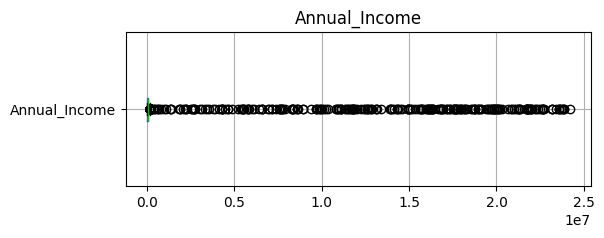

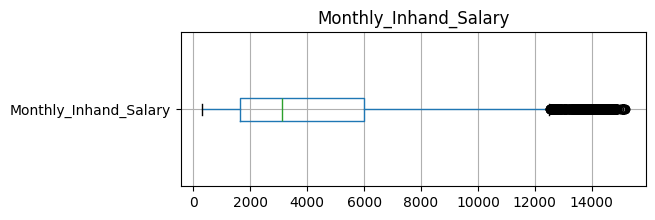

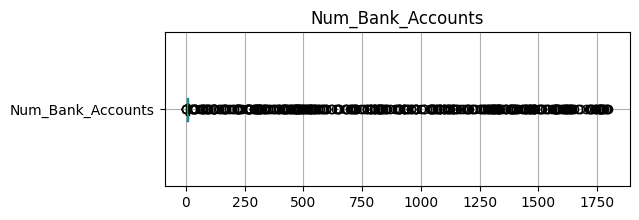

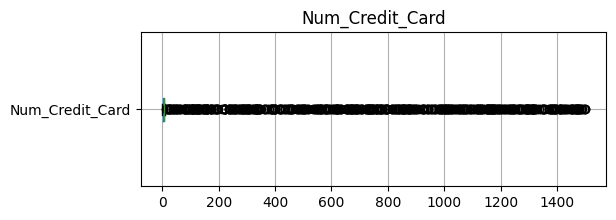

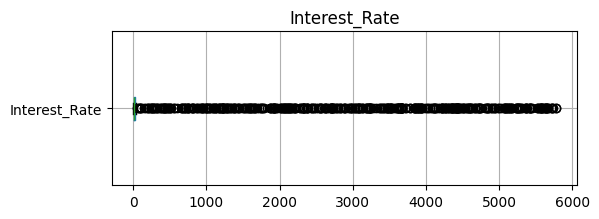

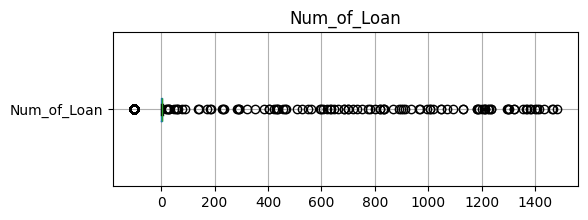

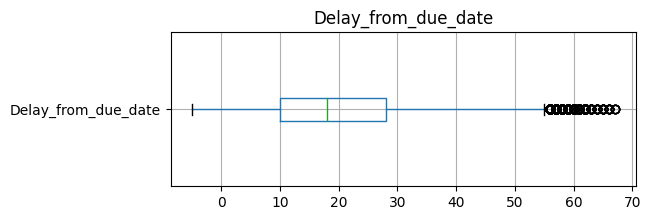

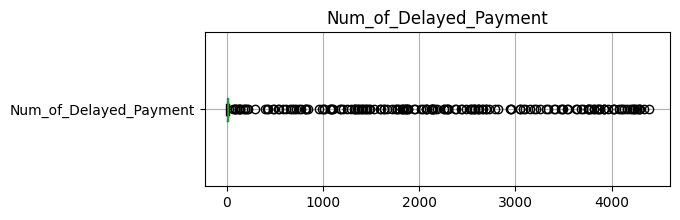

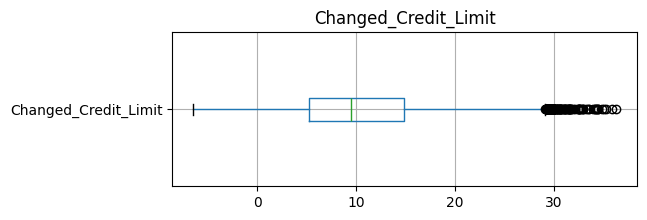

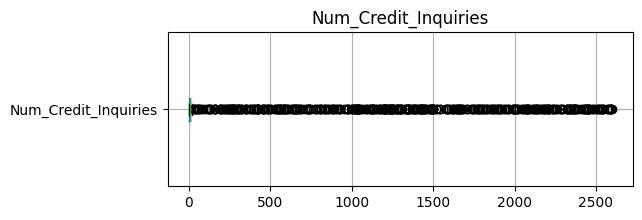

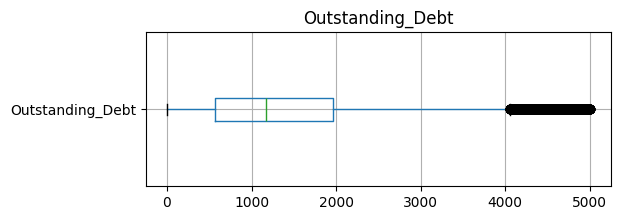

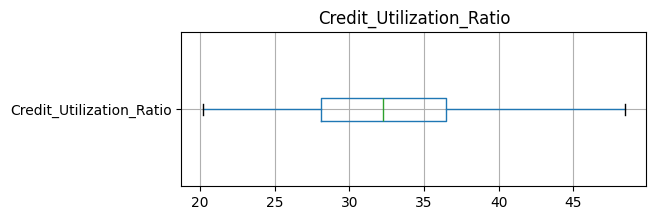

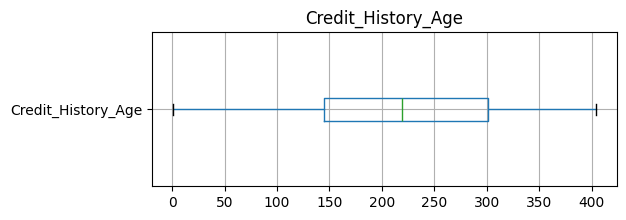

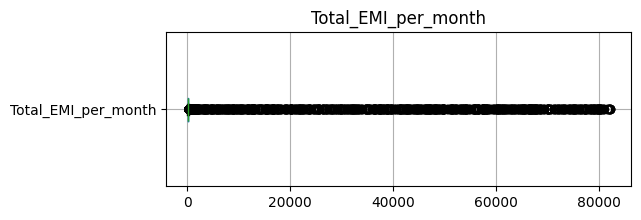

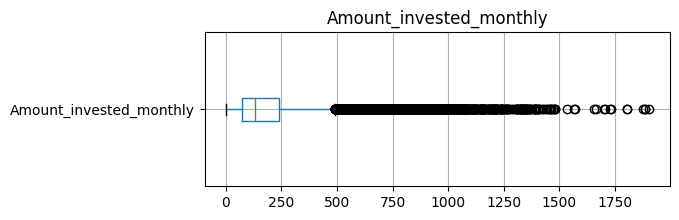

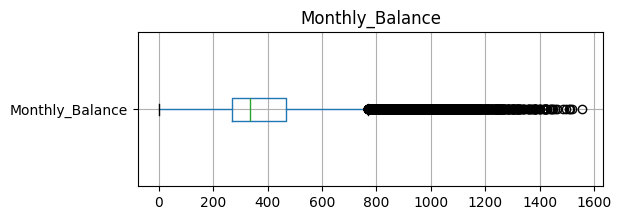

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
min,7005.93,303.645417,-1,0,1,-100,-5,-3,-6.43,0.0,0.23,20.172942,1.0,0.0,0.000000,0.899335
max,24188807.00,15167.180000,1798,1499,5775,1482,67,4388,36.29,2597.0,4998.07,48.489852,404.0,82236.0,1901.791695,1555.201051


In [33]:
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(6, 2))
    df[[col]].boxplot(vert=False)
    plt.title(col)
    plt.show()

df.select_dtypes(include="number").agg(["min", "max"])

Berdasarkan temuan di atas, saya kini sangat yakin bahwa hampir semua kolom memiliki nilai tidak valid dan tidak mungkin terjadi berdasarkan makna semantiknya:
- **Num_Bank_Accounts**, **Num_of_Loan**, dan **Num_of_Delayed_Payment** memiliki nilai negatif yang tidak masuk akal dalam konteks makna kolomnya. Misalnya: jumlah (*count*) tidak pernah bisa negatif. Nilai-nilai ini akan diubah menjadi NaN dan diimputasi nantinya.
- Nilai negatif pada **Delay_from_due_date** masih valid karena menunjukkan bahwa pembayaran dilakukan sebelum tanggal jatuh tempo. Dengan kata lain, pelanggan melunasi kewajibannya lebih awal sehingga jumlah hari keterlambatan tercatat sebagai nilai negatif.
- Nilai negatif pada **Changed_Credit_Limit** masih valid karena menunjukkan bahwa batas kredit (credit limit) pelanggan mengalami penurunan dibandingkan periode sebelumnya. Kondisi ini dapat terjadi ketika lembaga keuangan mengurangi limit kredit akibat perubahan profil risiko, riwayat pembayaran yang kurang baik, atau kebijakan internal perusahaan.
- **Annual_Income**, **Monthly_Inhand_Salary**, **Outstanding_Debt**, **Total_EMI_per_month**, **Amount_invested_monthly**, dan **Monthly_Balance** memiliki nilai *outlier* yang sangat ekstrem. Namun, karena secara semantik nilai tersebut masih masuk akal (seseorang bisa saja memiliki pendapatan yang sangat tinggi), nilai-nilai ini tidak akan dihapus melainkan akan ditangani menggunakan *RobustScaler* yang tahan terhadap *outlier*.

In [34]:
cols = ["Num_Bank_Accounts", "Num_of_Loan", "Num_of_Delayed_Payment"]
df[cols] = df[cols].mask(df[cols] < 0, np.nan)

In [35]:
df.select_dtypes(include="number").agg(["min", "max"])

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
min,7005.93,303.645417,0.0,0,1,0,-5,0,-6.43,0.0,0.23,20.172942,1.0,0.0,0.000000,0.899335
max,24188807.00,15167.180000,1798.0,1499,5775,1482,67,4388,36.29,2597.0,4998.07,48.489852,404.0,82236.0,1901.791695,1555.201051


In [36]:
for col in num_cols:
    vals = df[col].dropna()

    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    outliers = vals[(vals < LB) | (vals > UB)]
    outlier_pct = (len(outliers) / len(vals)) * 100

    skewness = vals.skew()

    print(f"Kolom: {col}")
    print(f"  Persentase Outlier: {outlier_pct:.2f}%")
    print(f"  Skewness: {skewness:.3f}")
    print("-" * 40)


Kolom: Annual_Income
  Persentase Outlier: 2.81%
  Skewness: 11.825
----------------------------------------
Kolom: Monthly_Inhand_Salary
  Persentase Outlier: 1.93%
  Skewness: 1.115
----------------------------------------
Kolom: Num_Bank_Accounts
  Persentase Outlier: 1.34%
  Skewness: 11.210
----------------------------------------
Kolom: Num_Credit_Card
  Persentase Outlier: 2.26%
  Skewness: 8.558
----------------------------------------
Kolom: Interest_Rate
  Persentase Outlier: 1.92%
  Skewness: 9.065
----------------------------------------
Kolom: Num_of_Loan
  Persentase Outlier: 0.46%
  Skewness: 18.900
----------------------------------------
Kolom: Delay_from_due_date
  Persentase Outlier: 4.07%
  Skewness: 0.958
----------------------------------------
Kolom: Num_of_Delayed_Payment
  Persentase Outlier: 0.78%
  Skewness: 14.656
----------------------------------------
Kolom: Changed_Credit_Limit
  Persentase Outlier: 0.67%
  Skewness: 0.637
-------------------------------

Menggunakan aturan umum bahwa lebih dari 5% *outlier*, *skewness* di bawah -0.5, atau *skewness* di atas 0.5 menandakan distribusi yang tidak normal, terlihat bahwa sebagian besar kolom tidak berdistribusi normal. Satu-satunya kolom yang berdistribusi normal hanyalah Credit_Utilization_Ratio dan Credit_History_Age. Oleh karena itu, kolom-kolom yang berdistribusi normal akan di-*scale* menggunakan *StandardScaler* untuk mempertahankan variansi semaksimal mungkin, sementara kolom non-normal akan menggunakan *RobustScaler* yang lebih tahan terhadap *outlier*. Meskipun model berbasis pohon seperti Random Forest dan XGBoost tidak memerlukan *scaling*, langkah ini tetap dilakukan untuk menjaga konsistensi pipeline dan mengantisipasi kemungkinan penggunaan model lain di masa mendatang.

# Pemeriksaan Nilai Hilang (*Missing Values*)

In [37]:
print("Persentase nilai hilang pada setiap kolom:")
df.isna().mean()

Persentase nilai hilang pada setiap kolom:


Annual_Income               0.00000
Monthly_Inhand_Salary       0.14332
Num_Bank_Accounts           0.00016
Num_Credit_Card             0.00000
Interest_Rate               0.00000
Num_of_Loan                 0.03916
Delay_from_due_date         0.00000
Num_of_Delayed_Payment      0.07556
Changed_Credit_Limit        0.02072
Num_Credit_Inquiries        0.02024
Credit_Mix                  0.00000
Outstanding_Debt            0.00000
Credit_Utilization_Ratio    0.00000
Credit_History_Age          0.08996
Payment_of_Min_Amount       0.00000
Total_EMI_per_month         0.00000
Amount_invested_monthly     0.08796
Payment_Behaviour           0.07408
Monthly_Balance             0.01172
Credit_Score                0.00000
Auto Loan                   0.00000
Credit-Builder Loan         0.00000
Debt Consolidation Loan     0.00000
Home Equity Loan            0.00000
Mortgage Loan               0.00000
Payday Loan                 0.00000
Personal Loan               0.00000
Student Loan                

Terdapat cukup banyak nilai hilang di setiap kolom. Namun, tidak ada kolom yang akan dihapus karena persentase nilai hilang semuanya di bawah 50%. Baris yang mengandung lebih dari 50% nilai hilang di seluruh atributnya akan dihapus, agar proses imputasi tidak membuat data terlalu artifisial akibat terlalu banyak substitusi nilai. Untuk kolom numerik yang berdistribusi normal (Credit_Utilization_Ratio dan Credit_History_Age), imputasi dilakukan menggunakan **mean** karena distribusinya simetris sehingga mean merupakan representasi yang tepat. Untuk kolom numerik lainnya yang tidak berdistribusi normal atau memiliki banyak *outlier*, imputasi dilakukan menggunakan **median** karena median lebih robust terhadap nilai ekstrem. Untuk kolom kategorikal, digunakan **modus** (*most_frequent*) melalui SimpleImputer. Imputasi dilakukan setelah pemisahan data *train-test* untuk menghindari *data leakage*.

In [38]:
df = df.dropna(thresh=len(df.columns) * 0.5)

In [39]:
print("Persentase nilai hilang pada setiap kolom:")
df.isna().mean()

Persentase nilai hilang pada setiap kolom:


Annual_Income               0.00000
Monthly_Inhand_Salary       0.14332
Num_Bank_Accounts           0.00016
Num_Credit_Card             0.00000
Interest_Rate               0.00000
Num_of_Loan                 0.03916
Delay_from_due_date         0.00000
Num_of_Delayed_Payment      0.07556
Changed_Credit_Limit        0.02072
Num_Credit_Inquiries        0.02024
Credit_Mix                  0.00000
Outstanding_Debt            0.00000
Credit_Utilization_Ratio    0.00000
Credit_History_Age          0.08996
Payment_of_Min_Amount       0.00000
Total_EMI_per_month         0.00000
Amount_invested_monthly     0.08796
Payment_Behaviour           0.07408
Monthly_Balance             0.01172
Credit_Score                0.00000
Auto Loan                   0.00000
Credit-Builder Loan         0.00000
Debt Consolidation Loan     0.00000
Home Equity Loan            0.00000
Mortgage Loan               0.00000
Payday Loan                 0.00000
Personal Loan               0.00000
Student Loan                

Tampaknya tidak ada perubahan pada persentase nilai hilang sama sekali, yang mengindikasikan bahwa semua baris memiliki kurang dari 50% nilai hilang, sehingga cukup andal untuk digunakan dalam pelatihan model.

# Pemeriksaan Data Duplikat

In [40]:
print(f"Total Duplikat: {df.duplicated().sum()}")

Total Duplikat: 0


Tidak ada data duplikat sehingga model tidak akan bias terhadap titik data tertentu dan dapat melakukan generalisasi ke seluruh dataset dengan baik.

# Pemeriksaan Korelasi dan Asosiasi

## Numerik × Numerik

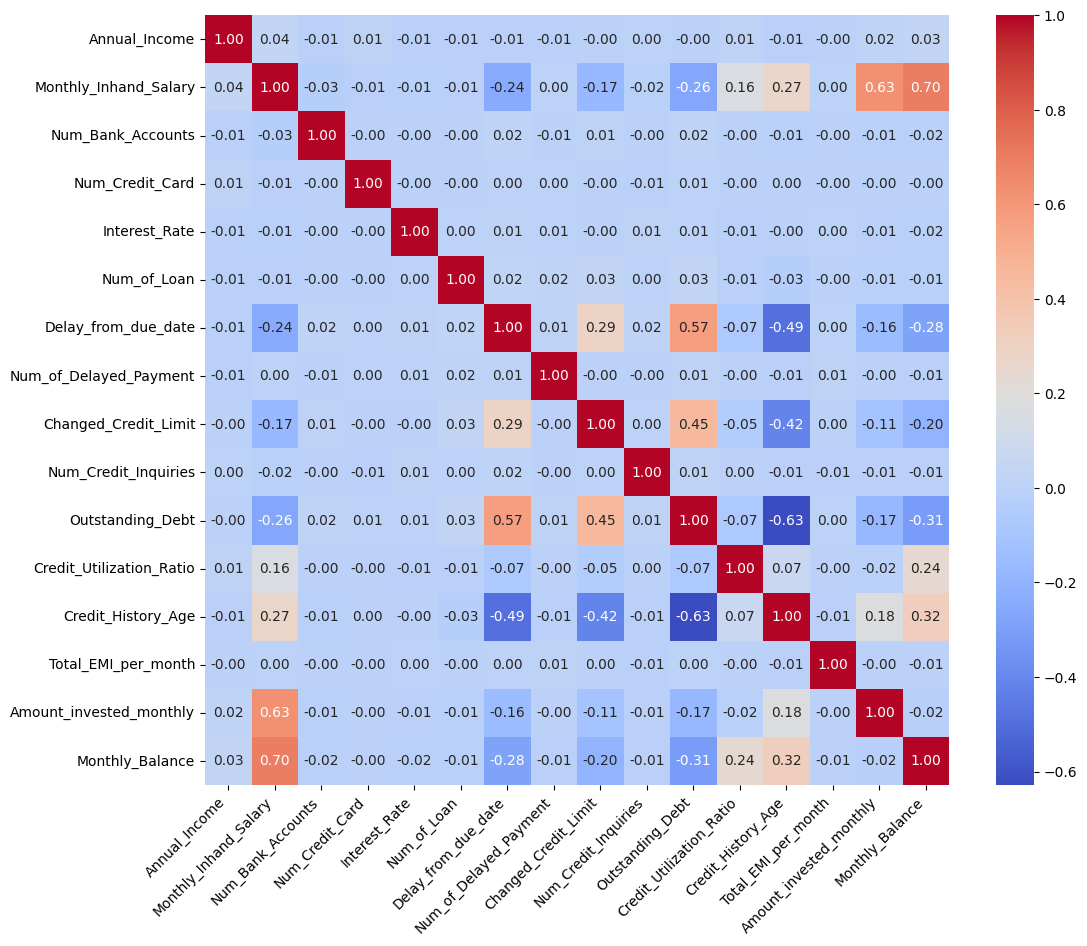

In [41]:
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Menggunakan tabel dari Research Gate (https://www.researchgate.net/figure/Interpretation-of-Correlation-Coefficient_tbl4_323336704) sebagai acuan, berikut interpretasi beberapa korelasi sedang hingga kuat yang memiliki nilai lebih dari atau sama dengan 0.40 dan kurang dari atau sama dengan -0.40:
- **Monthly_Inhand_Salary × Monthly_Balance** = 0.70 (Korelasi Positif Kuat). Gaji bulanan yang lebih tinggi cenderung menghasilkan saldo bulanan yang lebih tinggi. Hal ini mungkin disebabkan oleh individu berpenghasilan tinggi yang memiliki pendapatan lebih besar setelah menutupi pengeluaran pokoknya.
- **Amount_invested_monthly × Monthly_Inhand_Salary** = 0.63 (Korelasi Positif Kuat). Semakin tinggi gaji bulanan yang diterima seseorang, semakin besar pula jumlah dana yang diinvestasikan setiap bulan. Hal ini dapat terjadi karena individu dengan pendapatan yang lebih tinggi umumnya memiliki kapasitas finansial yang lebih besar untuk menyisihkan sebagian pendapatannya ke instrumen investasi setelah memenuhi.
- **Outstanding_Debt × Credit_History_Age** = -0.63 (Korelasi Negatif Sedang). Semakin lama riwayat kredit seseorang, semakin rendah jumlah utang yang masih tertunggak. Hal ini mungkin disebabkan oleh individu yang memiliki riwayat kredit lebih panjang cenderung memiliki pengalaman yang lebih baik dalam mengelola kewajiban finansial serta menjaga pembayaran utang secara konsisten.

**Catatan: Model berbasis pohon seperti Random Forest dan XGBoost tahan terhadap *multicollinearity* karena pemisahan fitur dilakukan berdasarkan *information gain* atau *feature importance*, bukan berdasarkan koefisien linier.**

## Kategorikal × Kategorikal

In [42]:
from scipy.stats import chi2_contingency
from itertools import combinations

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.values.sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

cat_cols = ['Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour','Auto Loan','Credit-Builder Loan','Debt Consolidation Loan','Home Equity Loan','Mortgage Loan','Payday Loan','Personal Loan','Student Loan']

In [43]:
pairwise_results = []

for col1, col2 in combinations(cat_cols, 2):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    cramers_v = (phi2 / min(k-1, r-1))**0.5
    pairwise_results.append({'Feature_1': col1, 'Feature_2': col2, 'Chi2': chi2, 'p_value': p, 'Cramers_V': cramers_v})

In [44]:
chi_pairwise_df = pd.DataFrame(pairwise_results).sort_values('p_value').T
chi_pairwise_df

,0,3,5,6,9,8,7,2,4,16,11,15,14,12,17,18,13,35,27,10,31,32,1,45,40,47,43,54,39,38,42,33,36,50,29,46,48,49,52,53,30,37,28,41,51,34,44,22,23,25,19,20,21,26,24
Feature_1,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Credit-Builder Loan,Auto Loan,Payment_of_Min_Amount,Auto Loan,Auto Loan,Credit_Mix,Home Equity Loan,Debt Consolidation Loan,Home Equity Loan,Debt Consolidation Loan,Personal Loan,Credit-Builder Loan,Credit-Builder Loan,Debt Consolidation Loan,Auto Loan,Credit-Builder Loan,Mortgage Loan,Auto Loan,Home Equity Loan,Home Equity Loan,Mortgage Loan,Payday Loan,Payday Loan,Auto Loan,Credit-Builder Loan,Auto Loan,Debt Consolidation Loan,Mortgage Loan,Credit-Builder Loan,Debt Consolidation Loan,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour
Feature_2,Payment_of_Min_Amount,Credit-Builder Loan,Home Equity Loan,Mortgage Loan,Student Loan,Personal Loan,Payday Loan,Auto Loan,Debt Consolidation Loan,Payday Loan,Auto Loan,Mortgage Loan,Home Equity Loan,Credit-Builder Loan,Personal Loan,Student Loan,Debt Consolidation Loan,Home Equity Loan,Credit-Builder Loan,Payment_Behaviour,Payday Loan,Personal Loan,Payment_Behaviour,Mortgage Loan,Home Equity Loan,Personal Loan,Personal Loan,Student Loan,Student Loan,Personal Loan,Payday Loan,Student Loan,Mortgage Loan,Personal Loan,Home Equity Loan,Payday Loan,Student Loan,Payday Loan,Personal Loan,Student Loan,Mortgage Loan,Payday Loan,Debt Consolidation Loan,Mortgage Loan,Student Loan,Debt Consolidation Loan,Student Loan,Home Equity Loan,Mortgage Loan,Personal Loan,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Student Loan,Payday Loan
Chi2,11913.966006,1487.448575,1420.069035,1401.463861,1321.159596,1264.302481,1248.997922,1246.087775,1166.523018,981.486176,979.574896,960.696954,946.491496,935.677935,921.090275,889.876095,806.151583,264.635549,197.294703,233.425043,194.023094,188.268931,241.141258,183.798104,180.325987,179.918321,172.072742,171.556304,170.48921,170.3154,154.613519,153.740643,147.255658,145.536856,144.684418,140.900545,139.033657,136.442468,133.129347,129.672774,124.348331,118.652439,114.430331,114.205219,113.164944,99.356249,82.185414,41.529825,39.279862,31.597653,28.367375,25.873185,21.663487,20.189175,20.043956
p_value,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000007,0.000031,0.000094,0.000607,0.001152,0.001226
Cramers_V,0.488139,0.243922,0.238333,0.236767,0.229883,0.224882,0.223517,0.223257,0.216011,0.19814,0.197947,0.19603,0.194576,0.193461,0.191947,0.188666,0.179572,0.102885,0.088836,0.071007,0.088096,0.08678,0.058928,0.085743,0.08493,0.084834,0.082963,0.082839,0.082581,0.082539,0.078642,0.07842,0.076748,0.076299,0.076075,0.075073,0.074574,0.073876,0.072974,0.07202,0.070526,0.068892,0.067655,0.067589,0.06728,0.063042,0.057336,0.042357,0.041193,0.036946,0.035007,0.033432,0.030592,0.029533,0.029426


H0: Kedua variabel bersifat independen (tidak ada hubungan)  
H1: Kedua variabel saling berkaitan  

Hasil uji *chi-squared* untuk setiap pasangan kolom kategorikal (tidak termasuk kolom target) menunjukkan bahwa semuanya memiliki *p-value* di bawah 0.05, artinya hipotesis nol ditolak dan terdapat cukup bukti untuk menyimpulkan bahwa semua pasangan kolom kategorikal (tidak termasuk kolom target) saling berkaitan satu sama lain.

In [45]:
cramers_pairwise_df = pd.DataFrame(pairwise_results).sort_values('Cramers_V', ascending=False).T
cramers_pairwise_df

,0,3,5,6,9,8,7,2,4,16,11,15,14,12,17,18,13,35,27,31,32,45,40,47,43,54,39,38,42,33,36,50,29,46,48,49,52,53,10,30,37,28,41,51,34,1,44,22,23,25,19,20,21,26,24
Feature_1,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Credit-Builder Loan,Auto Loan,Auto Loan,Auto Loan,Home Equity Loan,Debt Consolidation Loan,Home Equity Loan,Debt Consolidation Loan,Personal Loan,Credit-Builder Loan,Credit-Builder Loan,Debt Consolidation Loan,Auto Loan,Credit-Builder Loan,Mortgage Loan,Auto Loan,Home Equity Loan,Home Equity Loan,Mortgage Loan,Payday Loan,Payday Loan,Payment_of_Min_Amount,Auto Loan,Credit-Builder Loan,Auto Loan,Debt Consolidation Loan,Mortgage Loan,Credit-Builder Loan,Credit_Mix,Debt Consolidation Loan,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour
Feature_2,Payment_of_Min_Amount,Credit-Builder Loan,Home Equity Loan,Mortgage Loan,Student Loan,Personal Loan,Payday Loan,Auto Loan,Debt Consolidation Loan,Payday Loan,Auto Loan,Mortgage Loan,Home Equity Loan,Credit-Builder Loan,Personal Loan,Student Loan,Debt Consolidation Loan,Home Equity Loan,Credit-Builder Loan,Payday Loan,Personal Loan,Mortgage Loan,Home Equity Loan,Personal Loan,Personal Loan,Student Loan,Student Loan,Personal Loan,Payday Loan,Student Loan,Mortgage Loan,Personal Loan,Home Equity Loan,Payday Loan,Student Loan,Payday Loan,Personal Loan,Student Loan,Payment_Behaviour,Mortgage Loan,Payday Loan,Debt Consolidation Loan,Mortgage Loan,Student Loan,Debt Consolidation Loan,Payment_Behaviour,Student Loan,Home Equity Loan,Mortgage Loan,Personal Loan,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Student Loan,Payday Loan
Chi2,11913.966006,1487.448575,1420.069035,1401.463861,1321.159596,1264.302481,1248.997922,1246.087775,1166.523018,981.486176,979.574896,960.696954,946.491496,935.677935,921.090275,889.876095,806.151583,264.635549,197.294703,194.023094,188.268931,183.798104,180.325987,179.918321,172.072742,171.556304,170.48921,170.3154,154.613519,153.740643,147.255658,145.536856,144.684418,140.900545,139.033657,136.442468,133.129347,129.672774,233.425043,124.348331,118.652439,114.430331,114.205219,113.164944,99.356249,241.141258,82.185414,41.529825,39.279862,31.597653,28.367375,25.873185,21.663487,20.189175,20.043956
p_value,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000007,0.000031,0.000094,0.000607,0.001152,0.001226
Cramers_V,0.488139,0.243922,0.238333,0.236767,0.229883,0.224882,0.223517,0.223257,0.216011,0.19814,0.197947,0.19603,0.194576,0.193461,0.191947,0.188666,0.179572,0.102885,0.088836,0.088096,0.08678,0.085743,0.08493,0.084834,0.082963,0.082839,0.082581,0.082539,0.078642,0.07842,0.076748,0.076299,0.076075,0.075073,0.074574,0.073876,0.072974,0.07202,0.071007,0.070526,0.068892,0.067655,0.067589,0.06728,0.063042,0.058928,0.057336,0.042357,0.041193,0.036946,0.035007,0.033432,0.030592,0.029533,0.029426


Menggunakan tabel dari ResearchGate (https://www.researchgate.net/figure/Interpretation-of-Cramers-V-values_tbl4_382584046) sebagai acuan, berikut interpretasi untuk pasangan dengan nilai Cramér's V di atas 0.10 yang menunjukkan asosiasi sedang ke atas:
- **Credit_Mix dan Payment_of_Min_Amount** menunjukkan asosiasi yang paling bermakna secara keseluruhan, mengindikasikan bahwa kombinasi kredit seorang pelanggan memengaruhi kecenderungannya untuk hanya membayar jumlah minimum. Hal ini mungkin dipengaruhi oleh tekanan finansial dan kompleksitas kredit.
- Pasangan yang melibatkan kolom-kolom pinjaman (*loan*) umumnya memiliki asosiasi rendah satu sama lain, yang masuk akal karena memiliki satu jenis pinjaman tidak secara otomatis menentukan jenis pinjaman lainnya.

In [46]:
results = []

for col1, col2 in combinations(cat_cols, 2):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    cramers_v = np.sqrt((chi2 / n) / (min(r, k) - 1))
    results.append({'Feature_1': col1, 'Feature_2': col2, 'Chi2': chi2, 'p_value': p, 'Cramers_V': cramers_v})

cat_vs_target_summary = pd.DataFrame(results).sort_values('Cramers_V', ascending=False).T
cat_vs_target_summary

,0,3,5,6,9,8,7,2,4,16,11,15,14,12,17,18,13,35,27,31,32,45,40,47,43,54,39,38,42,33,36,50,29,46,48,49,52,53,10,30,37,28,41,51,34,1,44,22,23,25,19,20,21,26,24
Feature_1,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Credit-Builder Loan,Auto Loan,Auto Loan,Auto Loan,Home Equity Loan,Debt Consolidation Loan,Home Equity Loan,Debt Consolidation Loan,Personal Loan,Credit-Builder Loan,Credit-Builder Loan,Debt Consolidation Loan,Auto Loan,Credit-Builder Loan,Mortgage Loan,Auto Loan,Home Equity Loan,Home Equity Loan,Mortgage Loan,Payday Loan,Payday Loan,Payment_of_Min_Amount,Auto Loan,Credit-Builder Loan,Auto Loan,Debt Consolidation Loan,Mortgage Loan,Credit-Builder Loan,Credit_Mix,Debt Consolidation Loan,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour
Feature_2,Payment_of_Min_Amount,Credit-Builder Loan,Home Equity Loan,Mortgage Loan,Student Loan,Personal Loan,Payday Loan,Auto Loan,Debt Consolidation Loan,Payday Loan,Auto Loan,Mortgage Loan,Home Equity Loan,Credit-Builder Loan,Personal Loan,Student Loan,Debt Consolidation Loan,Home Equity Loan,Credit-Builder Loan,Payday Loan,Personal Loan,Mortgage Loan,Home Equity Loan,Personal Loan,Personal Loan,Student Loan,Student Loan,Personal Loan,Payday Loan,Student Loan,Mortgage Loan,Personal Loan,Home Equity Loan,Payday Loan,Student Loan,Payday Loan,Personal Loan,Student Loan,Payment_Behaviour,Mortgage Loan,Payday Loan,Debt Consolidation Loan,Mortgage Loan,Student Loan,Debt Consolidation Loan,Payment_Behaviour,Student Loan,Home Equity Loan,Mortgage Loan,Personal Loan,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Student Loan,Payday Loan
Chi2,11913.966006,1487.448575,1420.069035,1401.463861,1321.159596,1264.302481,1248.997922,1246.087775,1166.523018,981.486176,979.574896,960.696954,946.491496,935.677935,921.090275,889.876095,806.151583,264.635549,197.294703,194.023094,188.268931,183.798104,180.325987,179.918321,172.072742,171.556304,170.48921,170.3154,154.613519,153.740643,147.255658,145.536856,144.684418,140.900545,139.033657,136.442468,133.129347,129.672774,233.425043,124.348331,118.652439,114.430331,114.205219,113.164944,99.356249,241.141258,82.185414,41.529825,39.279862,31.597653,28.367375,25.873185,21.663487,20.189175,20.043956
p_value,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000007,0.000031,0.000094,0.000607,0.001152,0.001226
Cramers_V,0.488139,0.243922,0.238333,0.236767,0.229883,0.224882,0.223517,0.223257,0.216011,0.19814,0.197947,0.19603,0.194576,0.193461,0.191947,0.188666,0.179572,0.102885,0.088836,0.088096,0.08678,0.085743,0.08493,0.084834,0.082963,0.082839,0.082581,0.082539,0.078642,0.07842,0.076748,0.076299,0.076075,0.075073,0.074574,0.073876,0.072974,0.07202,0.071007,0.070526,0.068892,0.067655,0.067589,0.06728,0.063042,0.058928,0.057336,0.042357,0.041193,0.036946,0.035007,0.033432,0.030592,0.029533,0.029426


Hampir semua kolom kategorikal memiliki asosiasi sedang (>0.10), kuat (>0.15), hingga sangat kuat (>0.25) dengan kolom target, menjadikan mereka prediktor yang baik untuk *credit score* pelanggan.

## Numerik × Kategorikal

In [47]:
from scipy.stats import f_oneway

cat_cols = df.select_dtypes(include=["object", "bool"]).columns
num_cols = df.select_dtypes(include=["int64", "Int64", "float64"]).columns

In [48]:
results = []

for cat_col in cat_cols:
    for num_col in num_cols:
        groups = [df.loc[df[cat_col] == cat, num_col].dropna() for cat in df[cat_col].dropna().unique()]
        if len(groups) > 1 and all(len(g) > 1 for g in groups):
            f_stat, p_value = f_oneway(*groups)
            all_vals = np.concatenate(groups)
            grand_mean = all_vals.mean()
            ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
            ss_total = ((all_vals - grand_mean) ** 2).sum()
            eta_squared = ss_between / ss_total
            results.append({"Categorical": cat_col, "Numerical": num_col, "p_value": p_value, "eta_squared": eta_squared})
    
anova_df = pd.DataFrame(results)

In [49]:
print("Uji ANOVA diurutkan berdasarkan p-value:")
anova_df.sort_values("p_value", ascending=False).T

Uji ANOVA diurutkan berdasarkan p-value:


,3,146,29,183,169,109,50,179,48,93,45,178,180,82,128,141,73,71,130,105,4,80,144,167,61,35,163,83,100,39,160,116,67,13,173,114,37,87,112,20,19,98,147,51,137,18,99,34,164,16,125,96,162,53,77,132,131,151,89,135,119,64,176,2,66,52,189,84,153,115,0,68,41,23,157,117,103,36,9,149,55,148,101,121,57,25,165,185,32,85,7,181,69,133,5,21,75,91,155,139,171,187,59,123,40,107,142,126,158,174,190,110,78,27,129,38,94,11,44,42,145,65,113,161,177,97,81,152,43,168,104,136,88,72,120,62,184,79,159,191,143,175,30,111,127,95,86,14,49,70,102,134,150,118,166,182,63,56,124,156,92,108,172,140,106,188,76,154,60,58,22,17,26,24,28,31,1,6,54,47,46,33,8,10,15,12,74,90,122,138,170,186
Categorical,Credit_Mix,Payday Loan,Payment_of_Min_Amount,Student Loan,Personal Loan,Debt Consolidation Loan,Credit_Score,Student Loan,Credit_Score,Credit-Builder Loan,Payment_Behaviour,Student Loan,Student Loan,Credit-Builder Loan,Mortgage Loan,Mortgage Loan,Auto Loan,Auto Loan,Mortgage Loan,Debt Consolidation Loan,Credit_Mix,Credit-Builder Loan,Payday Loan,Personal Loan,Credit_Score,Payment_Behaviour,Personal Loan,Credit-Builder Loan,Debt Consolidation Loan,Payment_Behaviour,Personal Loan,Home Equity Loan,Auto Loan,Credit_Mix,Personal Loan,Home Equity Loan,Payment_Behaviour,Credit-Builder Loan,Home Equity Loan,Payment_of_Min_Amount,Payment_of_Min_Amount,Debt Consolidation Loan,Payday Loan,Credit_Score,Mortgage Loan,Payment_of_Min_Amount,Debt Consolidation Loan,Payment_Behaviour,Personal Loan,Payment_of_Min_Amount,Home Equity Loan,Debt Consolidation Loan,Personal Loan,Credit_Score,Auto Loan,Mortgage Loan,Mortgage Loan,Payday Loan,Credit-Builder Loan,Mortgage Loan,Home Equity Loan,Auto Loan,Student Loan,Credit_Mix,Auto Loan,Credit_Score,Student Loan,Credit-Builder Loan,Payday Loan,Home Equity Loan,Credit_Mix,Auto Loan,Payment_Behaviour,Payment_of_Min_Amount,Payday Loan,Home Equity Loan,Debt Consolidation Loan,Payment_Behaviour,Credit_Mix,Payday Loan,Credit_Score,Payday Loan,Debt Consolidation Loan,Home Equity Loan,Credit_Score,Payment_of_Min_Amount,Personal Loan,Student Loan,Payment_Behaviour,Credit-Builder Loan,Credit_Mix,Student Loan,Auto Loan,Mortgage Loan,Credit_Mix,Payment_of_Min_Amount,Auto Loan,Credit-Builder Loan,Payday Loan,Mortgage Loan,Personal Loan,Student Loan,Credit_Score,Home Equity Loan,Payment_Behaviour,Debt Consolidation Loan,Mortgage Loan,Home Equity Loan,Payday Loan,Personal Loan,Student Loan,Debt Consolidation Loan,Auto Loan,Payment_of_Min_Amount,Mortgage Loan,Payment_Behaviour,Credit-Builder Loan,Credit_Mix,Payment_Behaviour,Payment_Behaviour,Payday Loan,Auto Loan,Home Equity Loan,Personal Loan,Student Loan,Debt Consolidation Loan,Credit-Builder Loan,Payday Loan,Payment_Behaviour,Personal Loan,Debt Consolidation Loan,Mortgage Loan,Credit-Builder Loan,Auto Loan,Home Equity Loan,Credit_Score,Student Loan,Auto Loan,Payday Loan,Student Loan,Mortgage Loan,Personal Loan,Payment_of_Min_Amount,Debt Consolidation Loan,Home Equity Loan,Credit-Builder Loan,Credit-Builder Loan,Credit_Mix,Credit_Score,Auto Loan,Debt Consolidation Loan,Mortgage Loan,Payday Loan,Home Equity Loan,Personal Loan,Student Loan,Credit_Score,Credit_Score,Home Equity Loan,Payday Loan,Credit-Builder Loan,Debt Consolidation Loan,Personal Loan,Mortgage Loan,Debt Consolidation Loan,Student Loan,Auto Loan,Payday Loan,Credit_Score,Credit_Score,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Credit_Mix,Credit_Mix,Credit_Score,Payment_Behaviour,Payment_Behaviour,Payment_Behaviour,Credit_Mix,Credit_Mix,Credit_Mix,Credit_Mix,Auto Loan,Credit-Builder Loan,Home Equity Loan,Mortgage Loan,Personal Loan,Student Loan
Numerical,Num_Credit_Card,Num_Bank_Accounts,Total_EMI_per_month,Num_of_Delayed_Payment,Num_Credit_Inquiries,Total_EMI_per_month,Num_Bank_Accounts,Num_Credit_Card,Annual_Income,Total_EMI_per_month,Total_EMI_per_month,Num_Bank_Accounts,Interest_Rate,Num_Bank_Accounts,Annual_Income,Total_EMI_per_month,Num_Credit_Inquiries,

In [50]:
percentage = (anova_df["p_value"] > 0.05).mean() * 100
print(f"Total pasangan numerik-kategorikal dengan p-value > 0.05: {percentage:.2f}%")

Total pasangan numerik-kategorikal dengan p-value > 0.05: 40.62%


H0: Setiap perbedaan yang teramati pada *mean* sampel disebabkan oleh variasi acak  
H1: Terdapat setidaknya satu perbedaan *mean* sampel yang signifikan  

Sekitar 40.62% pasangan kolom numerik dan kategorikal tidak memiliki cukup bukti bahwa terdapat setidaknya satu perbedaan *mean* sampel yang signifikan, sehingga hipotesis nol tidak ditolak. Sementara itu, 59.38% sisanya memiliki bukti yang cukup sehingga hipotesis nol ditolak dan disimpulkan bahwa terdapat setidaknya satu perbedaan *mean* sampel yang signifikan.

In [51]:
print("Uji ANOVA diurutkan berdasarkan eta_squared (difilter hanya p <= 0.05):")
anova_df.sort_values("eta_squared", ascending=False).loc[anova_df["p_value"] <= 0.05].T

Uji ANOVA diurutkan berdasarkan eta_squared (difilter hanya p <= 0.05):


,10,6,12,28,47,22,24,26,54,8,58,60,33,15,46,31,1,17,186,90,170,122,76,138,188,140,172,74,154,108,92,106,156,124,56,49,63,14,182,166,118,150,134,102,70,86,30,95,127,111,175,143,191,159,79,184,62,120,72,88,136,104,168,43,152,81,97,177,161,113,44,65,145,42,11,38,94,129,27,78,110,190,174,158,126,142,40,107,123,59,187,171,139,155,91,75,21,32,5,7,133,69,181,9,25,57,55,85,185,165,101,121,148,149
Categorical,Credit_Mix,Credit_Mix,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,Payment_of_Min_Amount,Payment_of_Min_Amount,Payment_of_Min_Amount,Credit_Score,Credit_Mix,Credit_Score,Credit_Score,Payment_Behaviour,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Credit_Mix,Payment_of_Min_Amount,Student Loan,Credit-Builder Loan,Personal Loan,Home Equity Loan,Auto Loan,Mortgage Loan,Student Loan,Mortgage Loan,Personal Loan,Auto Loan,Payday Loan,Debt Consolidation Loan,Credit-Builder Loan,Debt Consolidation Loan,Payday Loan,Home Equity Loan,Credit_Score,Credit_Score,Credit_Score,Credit_Mix,Student Loan,Personal Loan,Home Equity Loan,Payday Loan,Mortgage Loan,Debt Consolidation Loan,Auto Loan,Credit-Builder Loan,Payment_of_Min_Amount,Credit-Builder Loan,Home Equity Loan,Debt Consolidation Loan,Personal Loan,Mortgage Loan,Student Loan,Payday Loan,Auto Loan,Student Loan,Credit_Score,Home Equity Loan,Auto Loan,Credit-Builder Loan,Mortgage Loan,Debt Consolidation Loan,Personal Loan,Payment_Behaviour,Payday Loan,Credit-Builder Loan,Debt Consolidation Loan,Student Loan,Personal Loan,Home Equity Loan,Payment_Behaviour,Auto Loan,Payday Loan,Payment_Behaviour,Credit_Mix,Payment_Behaviour,Credit-Builder Loan,Mortgage Loan,Payment_of_Min_Amount,Auto Loan,Debt Consolidation Loan,Student Loan,Personal Loan,Payday Loan,Home Equity Loan,Mortgage Loan,Payment_Behaviour,Debt Consolidation Loan,Home Equity Loan,Credit_Score,Student Loan,Personal Loan,Mortgage Loan,Payday Loan,Credit-Builder Loan,Auto Loan,Payment_of_Min_Amount,Payment_Behaviour,Credit_Mix,Credit_Mix,Mortgage Loan,Auto Loan,Student Loan,Credit_Mix,Payment_of_Min_Amount,Credit_Score,Credit_Score,Credit-Builder Loan,Student Loan,Personal Loan,Debt Consolidation Loan,Home Equity Loan,Payday Loan,Payday Loan
Numerical,Outstanding_Debt,Delay_from_due_date,Credit_History_Age,Credit_History_Age,Monthly_Balance,Delay_from_due_date,Changed_Credit_Limit,Outstanding_Debt,Delay_from_due_date,Changed_Credit_Limit,Outstanding_Debt,Credit_History_Age,Monthly_Inhand_Salary,Monthly_Balance,Amount_invested_monthly,Monthly_Balance,Monthly_Inhand_Salary,Monthly_Inhand_Salary,Outstanding_Debt,Outstanding_Debt,Outstanding_Debt,Outstanding_Debt,Credit_History_Age,Outstanding_Debt,Credit_History_Age,Credit_History_Age,Credit_History_Age,Outstanding_Debt,Outstanding_Debt,Credit_History_Age,Credit_History_Age,Outstanding_Debt,Credit_History_Age,Credit_History_Age,Changed_Credit_Limit,Monthly_Inhand_Salary,Monthly_Balance,Amount_invested_monthly,Delay_from_due_date,Delay_from_due_date,Delay_from_due_date,Delay_from_due_date,Delay_from_due_date,Delay_from_due_date,Delay_from_due_date,Delay_from_due_date,Amount_invested_monthly,Monthly_Balance,Monthly_Balance,Monthly_Balance,Monthly_Balance,Monthly_Balance,Monthly_Balance,Monthly_Balance,Monthly_Balance,Changed_Credit_Limit,Amount_invested_monthly,Changed_Credit_Limit,Changed_Credit_Limit,Changed_Credit_Limit,Changed_Credit_Limit,Changed_Credit_Limit,Changed_Credit_Limit,Credit_Utilization_Ratio,Changed_Credit_Limit,Monthly_Inhand_Salary,Monthly_Inhand_Salary,Monthly_Inhand_Salary,Monthly_Inhand_Salary,Monthly_Inhand_Salary,Credit_History_Age,Monthly_Inhand_Salary,Monthly_Inhand_Salary,Outstanding_Debt,Credit_Utilization_Ratio,Delay_from_due_date,Amount_invested_monthly,Monthly_Inhand_Salary,Credit_Utilization_Ratio,Amount_invested_monthly,Amount_invested_monthly,Amount_invested_monthly,Amount_invested_monthly,Amount_invested_monthly,Amount_invested_monthly,Amount_invested_monthly,Changed_Credit_Limit,Credit_Utilization_Ratio,Credit_Utilization_Ratio,Credit_Utilization_

Saya menggunakan tabel berikut sebagai acuan untuk menginterpretasikan kekuatan asosiasi berdasarkan nilai *eta-squared*: https://www.researchgate.net/figure/Interpretation-of-Eta-Squared-Values_tbl6_368801417. Berikut interpretasi untuk pasangan numerik-kategorikal yang memiliki nilai *eta-squared* di atas 0.06 yang menandakan efek sedang hingga besar:
- Kolom kategorikal yang mencerminkan **perilaku kredit** (Credit_Mix dan Payment_of_Min_Amount) menunjukkan asosiasi terkuat dengan **hasil finansial utama** (Outstanding_Debt, Annual_Income, Num_of_Loan), mengindikasikan bahwa kebiasaan pembayaran dan penggunaan kredit seseorang sangat erat kaitannya dengan situasi keuangan keseluruhannya.
- Kolom-kolom pinjaman (*loan*) memiliki *eta-squared* yang sangat rendah, menandakan bahwa jenis pinjaman yang dimiliki seseorang hampir tidak berkaitan dengan variabel numerik manapun.

## Pembagian Data (*Train-Test Split*)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Annual_Income             25000 non-null  float64
 1   Monthly_Inhand_Salary     21417 non-null  float64
 2   Num_Bank_Accounts         24996 non-null  float64
 3   Num_Credit_Card           25000 non-null  int64  
 4   Interest_Rate             25000 non-null  int64  
 5   Num_of_Loan               24021 non-null  Int64  
 6   Delay_from_due_date       25000 non-null  int64  
 7   Num_of_Delayed_Payment    23111 non-null  Int64  
 8   Changed_Credit_Limit      24482 non-null  float64
 9   Num_Credit_Inquiries      24494 non-null  float64
 10  Credit_Mix                25000 non-null  object 
 11  Outstanding_Debt          25000 non-null  float64
 12  Credit_Utilization_Ratio  25000 non-null  float64
 13  Credit_History_Age        22751 non-null  float64
 14  Paymen

In [53]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Credit_Score')
y = df['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [54]:
y_train = y_train.map({'Poor': 0, 'Standard': 1, 'Good': 2}).astype(int)
y_test  = y_test.map({'Poor': 0, 'Standard': 1, 'Good': 2}).astype(int)

In [55]:
X_train.head(5)

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Payday Loan,Personal Loan,Student Loan
19403,16608.80,1269.066667,10.0,6,15,6,28,18,16.64,9.0,Unknown,3103.97,36.241163,43.0,Yes,76.367702,32.514823,High_spent_Large_value_payments,258.024142,False,False,False,True,True,True,False,True
11426,123732.32,10416.026667,4.0,3,11,0,15,8,11.92,3.0,Unknown,1154.46,31.241928,332.0,No,0.000000,96.702973,High_spent_Large_value_payments,1184.899694,False,False,False,False,False,False,False,False
21908,42515.60,3447.966667,3.0,4,11,3,14,12,8.80,2.0,Good,629.75,31.313507,188.0,No,103.302665,74.622032,High_spent_Small_value_payments,426.871970,False,False,False,False,True,False,True,True
22638,52754.28,4205.190000,9.0,6,27,6,53,18,NaN,8.0,Bad,1624.09,37.120797,179.0,Yes,142.915191,171.058657,High_spent_Medium_value_payments,356.545151,True,True,True,False,True,False,False,False
5638,130433.68,10597.473333,1.0,849,10,0,-1,<NA>,7.35,1.0,Good,825.55,40.819432,318.0,No,0.000000,375.956793,High_spent_Medium_value_payments,933.790540,False,False,False,False,False,False,False,False


In [56]:
y_train.head(5)

19403    1
11426    1
21908    2
22638    1
5638     2
Name: Credit_Score, dtype: int64

In [57]:
X_test.head(5)

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Payday Loan,Personal Loan,Student Loan
11416,140357.320,11636.443333,5.0,7,11,0,33,8,14.35,3.0,Standard,990.03,30.095156,260.0,Yes,0.000000,762.922644,Low_spent_Medium_value_payments,680.721689,False,False,False,False,False,False,False,False
1051,86638.520,7333.876667,1.0,4,4,4,12,9,5.37,1.0,Good,1007.84,30.674856,328.0,NM,241.813448,326.805305,Low_spent_Small_value_payments,454.768913,True,False,True,False,False,False,True,True
17157,26686.140,2284.845000,4.0,6,19,6,10,10,11.81,4.0,Standard,220.17,32.711552,101.0,Yes,38084.000000,237.876724,Low_spent_Small_value_payments,199.215193,False,False,False,True,False,False,False,False
11052,8664.405,872.033750,6.0,7,13,4,30,19,15.00,11.0,Standard,317.71,37.314169,149.0,Yes,28.714510,101.566595,Low_spent_Small_value_payments,246.922271,True,True,False,False,False,False,True,False
11472,71131.530,6148.627500,7.0,8,16,6,28,23,8.86,5.0,Unknown,1168.61,33.001867,232.0,Yes,222.433473,61.286561,High_spent_Large_value_payments,571.142716,True,True,False,False,False,True,False,True


In [58]:
y_test.head(5)

11416    1
1051     1
17157    1
11052    1
11472    1
Name: Credit_Score, dtype: int64

## Membangun *Pipeline*

In [59]:
std_num_cols = ["Credit_Utilization_Ratio", "Credit_History_Age"]
robust_num_cols = ["Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate", "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment", "Changed_Credit_Limit", "Num_Credit_Inquiries", "Outstanding_Debt", "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance"]
cat_ohe_cols = ["Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour"]
passthrough_cols = ["Auto Loan", "Credit-Builder Loan", "Debt Consolidation Loan", "Home Equity Loan", "Mortgage Loan", "Payday Loan", "Personal Loan", "Student Loan"]

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

std_num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

robust_num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("std_num", std_num_pipeline, std_num_cols),
        ("robust_num", robust_num_pipeline, robust_num_cols),
        ("cat", cat_pipeline, cat_ohe_cols),
        ("pass", "passthrough", passthrough_cols)
    ],
    remainder="drop"
)

# Perbandingan 5 Model Tree

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

tree_pipelines = {
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Extra Trees": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="mlogloss"
        ))
    ])
}

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_rows = []
fitted_tree_pipelines = {}
predictions_by_model = {}

for model_name, pipeline in tree_pipelines.items():
    pipeline.fit(X_train, y_train)
    fitted_tree_pipelines[model_name] = pipeline
    model_pred = pipeline.predict(X_test)
    predictions_by_model[model_name] = model_pred
    comparison_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, model_pred),
        "Precision": precision_score(y_test, model_pred, average="weighted"),
        "Recall": recall_score(y_test, model_pred, average="weighted"),
        "F1 Score": f1_score(y_test, model_pred, average="weighted"),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(by=["F1 Score", "Accuracy"], ascending=False).reset_index(drop=True)
best_model_name = comparison_df.loc[0, "Model"]
best_pipeline = fitted_tree_pipelines[best_model_name]
best_model = best_pipeline.named_steps["model"]
best_pred = predictions_by_model[best_model_name]

rf_pipeline = fitted_tree_pipelines["Random Forest"]
xgb_pipeline = fitted_tree_pipelines["XGBoost"]
rf_pred = predictions_by_model["Random Forest"]
xgb_pred = predictions_by_model["XGBoost"]

In [62]:
print("Perbandingan 5 model tree yang kompatibel dengan pipeline:")
display(
    comparison_df.style.format(
        {
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1 Score": "{:.4f}",
        }
    )
)
print(f"Model terbaik berdasarkan F1 Score: {best_model_name}")
print(f"F1 Score terbaik: {comparison_df.loc[0, 'F1 Score']:.4f}")

Perbandingan 5 model tree yang kompatibel dengan pipeline:


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.7352,0.7347,0.7352,0.7347
1,XGBoost,0.7188,0.7176,0.7188,0.7177
2,Extra Trees,0.7114,0.7123,0.7114,0.7112
3,Gradient Boosting,0.7014,0.7012,0.7014,0.6999
4,Decision Tree,0.6276,0.6263,0.6276,0.6268


Model terbaik berdasarkan F1 Score: Random Forest
F1 Score terbaik: 0.7347


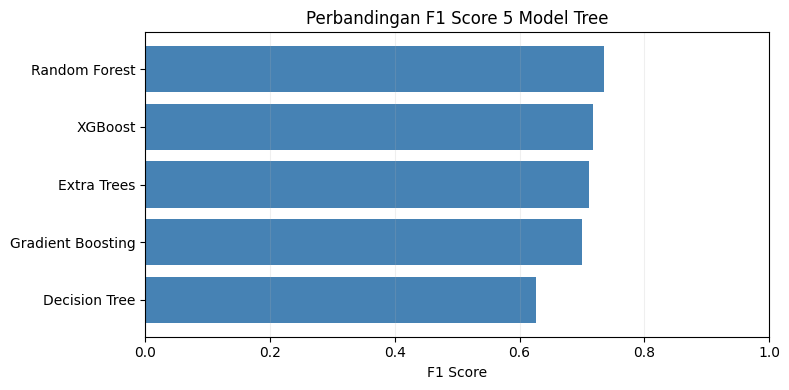

In [63]:
comparison_plot = comparison_df.sort_values(by="F1 Score", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(comparison_plot["Model"], comparison_plot["F1 Score"], color="steelblue")
plt.xlabel("F1 Score")
plt.title("Perbandingan F1 Score 5 Model Tree")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

In [64]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('std_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Credit_Utilization_Ratio',
                                                   'Credit_History_Age']),
                                                 ('robust_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Annual_Income',
                                                   'Monthly_Inhand_Salary',
                                                   'Num_B...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Credit_Mix',
                                                   'Payment_of_Min_Amount',
                                                   'Payment_Behaviour']),
                                                 ('pass', 'passthrough',
                                                  ['Auto Loan',
                                                   'Credit-Builder Loan',
                                                   'Debt Consolidation Loan',
                                                   'Home Equity Loan',
                                                   'Mortgage Loan',
                                                   'Payday Loan',
                                                   'Personal Loan',
                                                   'Student Loan'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [65]:
rf_pred = rf_pipeline.predict(X_test)
print("Metrik Random Forest (Sebelum Hyperparameter Tuning):")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.6f}")
print(f"Precision: {precision_score(y_test, rf_pred, average='weighted'):.6f}")
print(f"Recall:    {recall_score(y_test, rf_pred, average='weighted'):.6f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred, average='weighted'):.6f}")

Metrik Random Forest (Sebelum Hyperparameter Tuning):
Accuracy:  0.735200
Precision: 0.734710
Recall:    0.735200
F1 Score:  0.734689


Mengingat kolom target yang cukup tidak seimbang, diputuskan untuk menggunakan *class weights* guna menyeimbangkan pembelajaran tanpa mengubah distribusi data asli, menghindari sampel sintetis atau duplikat. *Oversampling* dan *undersampling* dapat menambah *noise* atau membuang informasi yang berguna sehingga tidak akan digunakan di sini.

In [66]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", RandomForestClassifier(class_weight="balanced", random_state=1, n_jobs=-1))])

In [67]:
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
print("Metrik Random Forest (Sebelum Hyperparameter Tuning):")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.6f}")
print(f"Precision: {precision_score(y_test, rf_pred, average='weighted'):.6f}")
print(f"Recall:    {recall_score(y_test, rf_pred, average='weighted'):.6f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred, average='weighted'):.6f}")

Metrik Random Forest (Sebelum Hyperparameter Tuning):
Accuracy:  0.729000
Precision: 0.727710
Recall:    0.729000
F1 Score:  0.727050


Hasil pengujian menunjukkan bahwa Random Forest dengan *balanced class weights* memperoleh performa yang sedikit lebih rendah dibandingkan Random Forest tanpa class weights. Hal ini menunjukkan bahwa tingkat ketidakseimbangan pada target belum cukup tinggi untuk memerlukan penyesuaian bobot kelas, sehingga pemberian bobot tambahan pada kelas minoritas justru tidak memberikan manfaat dan sedikit menurunkan kemampuan model dalam melakukan generalisasi. Oleh karena itu, model Random Forest tanpa class weights dipilih sebagai model akhir karena menghasilkan performa yang lebih baik secara keseluruhan.

In [76]:
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

rf_search_space = {
    "model__n_estimators": Integer(100, 500),
    "model__max_depth": Integer(3, 20),
    "model__min_samples_split": Integer(2, 20)
}

rf_pipeline = fitted_tree_pipelines["Random Forest"]
rf_bayes = BayesSearchCV(estimator=rf_pipeline, search_spaces=rf_search_space, n_iter=20, scoring='f1_weighted',cv=3, n_jobs=-1, random_state=1)

In [77]:
rf_bayes.fit(X_train, y_train)
print("Parameter terbaik RF:", rf_bayes.best_params_)

Parameter terbaik RF: OrderedDict({'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 429})


In [91]:
rf_pred = rf_bayes.predict(X_test)
print("Metrik Random Forest (Setelah Hyperparameter Tuning):")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.6f}")
print(f"Precision: {precision_score(y_test, rf_pred, average='weighted'):.6f}")
print(f"Recall:    {recall_score(y_test, rf_pred, average='weighted'):.6f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred, average='weighted'):.6f}\n")

Metrik Random Forest (Setelah Hyperparameter Tuning):
Accuracy:  0.733200
Precision: 0.733476
Recall:    0.733200
F1 Score:  0.733026



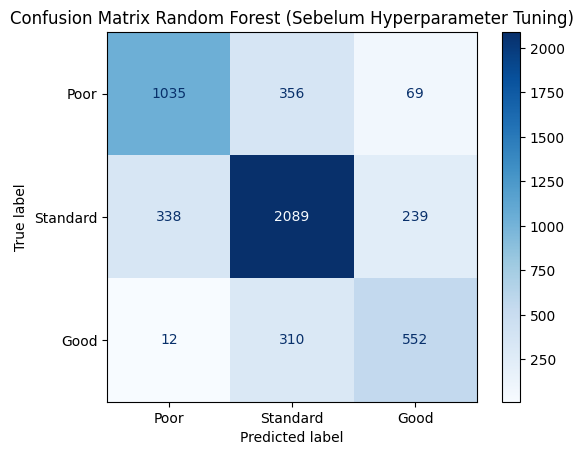

In [94]:
from sklearn.metrics import ConfusionMatrixDisplay

rf_pred = rf_pipeline.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=['Poor','Standard','Good'], cmap='Blues', values_format='d')
plt.title('Confusion Matrix Random Forest (Sebelum Hyperparameter Tuning)')
plt.show()

In [95]:
from sklearn.metrics import classification_report

print("Laporan Klasifikasi Random Forest (Sebelum Hyperparameter Tuning):")
print(classification_report(y_test, rf_pred, digits=4, target_names=['Poor', 'Standard', 'Good']))

Laporan Klasifikasi Random Forest (Sebelum Hyperparameter Tuning):
              precision    recall  f1-score   support

        Poor     0.7473    0.7089    0.7276      1460
    Standard     0.7583    0.7836    0.7707      2666
        Good     0.6419    0.6316    0.6367       874

    accuracy                         0.7352      5000
   macro avg     0.7158    0.7080    0.7117      5000
weighted avg     0.7347    0.7352    0.7347      5000



# Evaluasi Model

Meskipun kolom target cukup tidak seimbang, ternyata perbedaan antara nilai Accuracy dan F1 Score pada kedua model terbaik (Random Forest dan XGBoost) tidak terlalu jauh dan hampir setara. Hal ini menandakan bahwa model sudah cukup mampu menangani ketidakseimbangan kelas secara wajar dan tidak terlalu bias ke kelas mayoritas.

Akurasi Random Forest mencapai 73.68%, artinya model berhasil memprediksi kelas dengan benar sebanyak 73.52% dari keseluruhan data uji. Nilai Precision, Recall, dan F1 Score yang hampir sama dengan Accuracy mengindikasikan bahwa model berhasil menyeimbangkan *trade-off* antara *false positive* dan *false negative* dengan cukup baik. F1 Score (weighted) dipilih sebagai metrik utama karena dataset ini memiliki distribusi kelas yang tidak seimbang di mana kelas Standard mendominasi sementara kelas Good memiliki proporsi paling kecil. Jika hanya mengandalkan Accuracy, model yang selalu memprediksi "Standard" pun bisa mendapatkan nilai tinggi meskipun tidak benar-benar berguna. F1 Score yang menggunakan average='weighted' memperhitungkan kontribusi tiap kelas secara proporsional sehingga lebih jujur dalam mengukur performa model secara menyeluruh, termasuk pada kelas minoritas.

Setelah *hyperparameter tuning* menggunakan BayesSearchCV dengan ruang pencarian pada n_estimators, max_depth, dan min_samples_split sebanyak 20 iterasi dan 3-fold *cross-validation*, model Random Forest menghasilkan performa yang lebih jelek pada data uji sehingga akan digunakan base model saja. Berdasarkan *confusion matrix* dan *classification report*, terlihat jelas mengapa performa prediksi untuk kelas 'Good' lebih rendah dibandingkan kelas lainnya. Hal ini disebabkan oleh ketidakseimbangan data di mana 'Good' adalah kelas minoritas sementara 'Standard' adalah mayoritas. Meskipun demikian, dari sisi *deployment*, model ini sudah cukup siap untuk digunakan dalam mengotomasi proses persetujuan pinjaman dan penilaian risiko kredit tanpa model terlalu bias terhadap kelompok demografis tertentu, melainkan lebih berfokus pada perilaku dan kemampuan kredit pelanggan.

# Analisis *Feature Importance*

In [73]:
best_model_name_for_importance = best_model_name
best_model_for_importance = best_pipeline.named_steps["model"]
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = best_model_for_importance.feature_importances_
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=False)

In [74]:
print(f"10 Fitur Terpenting pada model terbaik ({best_model_name_for_importance})")
print(feat_imp.head(10))

10 Fitur Terpenting pada model terbaik (Random Forest)
                                Feature  Importance
12         robust_num__Outstanding_Debt    0.109948
6             robust_num__Interest_Rate    0.080288
10     robust_num__Changed_Credit_Limit    0.060815
8       robust_num__Delay_from_due_date    0.060571
1           std_num__Credit_History_Age    0.053210
15          robust_num__Monthly_Balance    0.046066
0     std_num__Credit_Utilization_Ratio    0.045995
14  robust_num__Amount_invested_monthly    0.044982
11     robust_num__Num_Credit_Inquiries    0.044698
2             robust_num__Annual_Income    0.044407


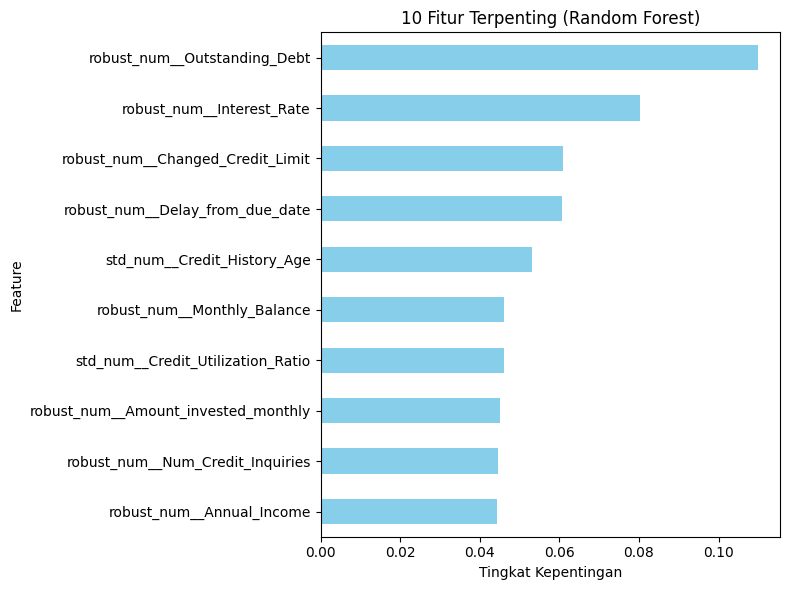

In [75]:
feat_imp.head(10).plot.barh(x="Feature", y="Importance", figsize=(8, 6), color="skyblue", legend=False)
plt.gca().invert_yaxis()
plt.xlabel("Tingkat Kepentingan")
plt.title(f"10 Fitur Terpenting ({best_model_name_for_importance})")
plt.tight_layout()
plt.show()

- **Beban utang dan biaya kredit** mendominasi prediksi di mana fitur-fitur seperti Outstanding_Debt, Interest_Rate, dan Delay_from_due_date memiliki importance tertinggi. Hal ini mengindikasikan bahwa jumlah utang yang masih dimiliki, tingkat bunga yang dikenakan, serta keterlambatan pembayaran merupakan faktor utama yang memengaruhi klasifikasi credit score. Kondisi ini kemungkinan terjadi karena ketiga faktor tersebut secara langsung mencerminkan tingkat risiko dan kemampuan nasabah dalam mengelola kewajiban kreditnya.
- **Perubahan dan riwayat kredit** juga memberikan pengaruh yang besar, di mana fitur-fitur seperti Changed_Credit_Limit, Credit_History_Age, dan Num_Credit_Inquiries menunjukkan bahwa dinamika penggunaan kredit serta panjang riwayat kredit berperan penting dalam prediksi. Hal ini karena nasabah dengan riwayat kredit yang lebih panjang dan stabil umumnya memiliki profil risiko yang lebih mudah dievaluasi oleh lembaga keuangan, sementara perubahan limit kredit dan banyaknya permintaan kredit dapat menjadi indikator perubahan kondisi finansial seseorang.
- **Kapasitas dan aktivitas finansial** berperan secara sekunder, di mana Monthly_Balance, Credit_Utilization_Ratio, Amount_invested_monthly, dan Annual_Income berkontribusi secara moderat terhadap prediksi. Temuan ini menunjukkan bahwa meskipun tingkat pendapatan, saldo bulanan, serta aktivitas investasi tetap berpengaruh terhadap credit score, faktor-faktor tersebut tidak sepenting indikator yang secara langsung menggambarkan pengelolaan utang dan perilaku kredit nasabah.

# Tautan Video Presentasi

Tautan Video Presentasi: